# Weighted Survey Logistic Regression for Probable Depression in NHANES 2017–2018

## Step 1: Load libraries

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Step 2: Loading dataset

In [26]:
df = pd.read_csv("merged_final_dataset_eda_nb5.csv")
print(df.shape)
df.columns

(5533, 45)


Index(['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060',
       'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100', 'AgeYears_RIDAGEYR',
       'Sex_RIAGENDR', 'RaceEthnicity1_RIDRETH1', 'EducationAdult_DMDEDUC2',
       'MaritalStatus_DMDMARTL', 'HouseholdIncome_INDDHHIN2',
       'FamilyIncome_INDFMIN2', 'PovertyIncomeRatio_INDFMPIR',
       'BornInUS_DMDBORN4', 'CitizenshipStatus_DMDCITZN', 'YearsInUS_DMDYRSUS',
       'HouseholdSize_DMDHHSIZ', 'FamilySize_DMDFMSIZ',
       'HH_ChildrenUnder6_DMDHHSZA', 'HH_Children6to17_DMDHHSZB',
       'HH_Adults60Plus_DMDHHSZE', 'InterviewWeight_WTINT2YR',
       'ExamWeight_WTMEC2YR', 'PSU_SDMVPSU', 'Strata_SDMVSTRA',
       'phq9_items_answered', 'probable_depression', 'suicidal_ideation',
       'phq9_total_score', 'SurveyCycle_SDDSRVYR', 'ExamMonth_RIDEXMON',
       'MilitaryService_DMQMILIZ', 'InterviewStatus_RIDSTATR',
       'missing_per_participant', 'age_group', 'Gender_Label', 'pir_group',
       'Race_Label', 'Education_Label'],

In [27]:
df.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,SurveyCycle_SDDSRVYR,ExamMonth_RIDEXMON,MilitaryService_DMQMILIZ,InterviewStatus_RIDSTATR,missing_per_participant,age_group,Gender_Label,pir_group,Race_Label,Education_Label
0,93705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,2,2,2,2,60+,Female,Low (≤1),Non-Hispanic Black,9–11th grade
1,93706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,2,2,2,7,18-29,Male,NaN,Other Race/Multi-racial,NaN
2,93708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,2,2,2,1,60+,Female,Mid (1–2),Other Race/Multi-racial,Less than 9th grade
3,93709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10,1,2,2,12,60+,Female,Low (≤1),Non-Hispanic Black,Some college/AA
4,93711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,2,2,2,0,45-59,Male,High (>2),Other Race/Multi-racial,College graduate Or above


## Step 3: Creating the analytic (complete-case) dataset

In [28]:
model_df = df[[
    "probable_depression",
    "AgeYears_RIDAGEYR",
    "Sex_RIAGENDR",
    "RaceEthnicity1_RIDRETH1",
    "EducationAdult_DMDEDUC2",
    "MaritalStatus_DMDMARTL",
    "PovertyIncomeRatio_INDFMPIR",
    "InterviewWeight_WTINT2YR",
    "pir_group"
]].copy()

# Replace invalid codes
model_df["EducationAdult_DMDEDUC2"] = model_df["EducationAdult_DMDEDUC2"].replace([7,9], np.nan)
model_df["MaritalStatus_DMDMARTL"] = model_df["MaritalStatus_DMDMARTL"].replace([77,99], np.nan)

analytic_df = model_df.dropna().copy()

**Comments:** I first created a subset of the dataset by specifying the outcome variable, the important sociodemographic predictors, and the NHANES interview weight that is required for the analysis. I then proceeded to recode the invalid survey response categories such as “Refused” and “Don’t know” as missing. I also created a complete case analysis dataset by deleting cases with missing values.

## Step 4 : Creating labeled categorical variables

In [29]:
sex_labels = {1: "Male", 2: "Female"}

race_labels = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
}

education_labels = {
    1: "Less than 9th grade",
    2: "9–11th grade",
    3: "High school/GED",
    4: "Some college/AA",
    5: "College graduate or above"
}

marital_labels = {
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Living with partner"
}

analytic_df["Sex_RIAGENDR"] = analytic_df["Sex_RIAGENDR"].map(sex_labels)
analytic_df["RaceEthnicity1_RIDRETH1"] = analytic_df["RaceEthnicity1_RIDRETH1"].map(race_labels)
analytic_df["EducationAdult_DMDEDUC2"] = analytic_df["EducationAdult_DMDEDUC2"].map(education_labels)
analytic_df["MaritalStatus_DMDMARTL"] = analytic_df["MaritalStatus_DMDMARTL"].map(marital_labels)

**Comments:** For categorical variables, the numeric NHANES code was mapped onto more interpretable category labels for sex, race and ethnicity, education level, and marital status. This enhances the interpretability of the data for subsequent analysis.

## Step 5: Creating survey weight variable

In [35]:
weights = analytic_df["InterviewWeight_WTINT2YR"]

**Comments**:To account for the complex survey design, interview weights were used to obtain representative results. Since all variables used in this study were derived from the interview portion, the interview weight variable was chosen for all weighted procedures.

## Step 6: Overall Prevalence

### Step 6.1 : Weighted Prevalence by depression

In [36]:
weighted_prevalence = np.average(
    analytic_df["probable_depression"],
    weights=weights
)

print("Weighted prevalence:", weighted_prevalence)

Weighted prevalence: 0.07913293968305271


**Comments:** Weighted prevalence of probable depression was computed using interview weights provided by NHANES data to obtain a representative weighted prevalence. Estimated weighted prevalence is approximately 0.079, meaning that approximately 7.9% of the adult US population is classified as having probable depression.

### Step 6.2: Weighted prevalence by gender

In [37]:
gender_prevalence = analytic_df.groupby("Sex_RIAGENDR").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

gender_prevalence = gender_prevalence.reindex(["Male", "Female"])

gender_prevalence



,Weighted_Prevalence
Sex_RIAGENDR,
Male,0.062672
Female,0.094227


**Comments:** The weighted prevalence of probable depression was also estimated for females and males separately by using the interview weights provided by the NHANES survey. The findings show that the prevalence of probable depression is higher among females than among males. Females have a higher prevalence of 9.4%, while the prevalence among males is significantly lower at 6.3%.

### Step 6.3 : Weighted prevalence by race

In [38]:
race_prevalence = analytic_df.groupby("RaceEthnicity1_RIDRETH1").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

race_prevalence = race_prevalence.reindex([
    "Mexican American",
    "Other Hispanic",
    "Non-Hispanic White",
    "Non-Hispanic Black",
    "Other Race"
])

race_prevalence

,Weighted_Prevalence
RaceEthnicity1_RIDRETH1,
Mexican American,0.063841
Other Hispanic,0.079043
Non-Hispanic White,0.079405
Non-Hispanic Black,0.074277
Other Race,0.094902


**Comments:** Weighted prevalence of probable depression was estimated across race/ethnicity groups using interview weights provided by the survey design data. The results show that there is a variation across race/ethnicity groups, with the highest prevalence found in individuals classified as Other Race, approximately 9.5%, and the lowest found in Mexican American individuals, approximately 6.4%. Other race/ethnicity groups, such as Other Hispanic, Non-Hispanic Whites, and Non-Hispanic Blacks, have similar prevalence levels, ranging approximately between 7.4% and 7.9%. This shows that there is a variation in depression prevalence across race/ethnicity groups.

### Step 6.4 : Weighted prevalence by education

In [20]:
education_prevalence = df.groupby("EducationAdult_DMDEDUC2").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

education_prevalence = education_prevalence.reindex([
    "Less than 9th grade",
    "9–11th grade",
    "High school/GED",
    "Some college/AA",
    "College graduate or above"
])

education_prevalence

,Weighted_Prevalence
EducationAdult_DMDEDUC2,
Less than 9th grade,0.119496
9–11th grade,0.124747
High school/GED,0.086137
Some college/AA,0.095329
College graduate or above,0.044992


**Comments:** The weighted prevalence of probable depression has been estimated across education levels by using NHANES interview weights to control for survey design. It is evident from the results that there is a clear trend in depression prevalence with respect to education level. The highest depression prevalence is observed in individuals with less than a high school education level, specifically in individuals with 9-11th grade education at a rate of 12.5%, followed by individuals with less than 9th grade education at a rate of 11.9%. On the other hand, individuals with a college degree and above have the lowest depression prevalence rate at 4.5%.

### Step 6.5 : Weighted prevalence by Marital Status

In [45]:
marital_prevalence = analytic_df.groupby("MaritalStatus_DMDMARTL").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

marital_prevalence = marital_prevalence.reindex([
    "Married",
    "Widowed",
    "Divorced",
    "Separated",
    "Never married",
    "Living with partner"
])

marital_prevalence

,Weighted_Prevalence
MaritalStatus_DMDMARTL,
Married,0.052189
Widowed,0.116113
Divorced,0.124784
Separated,0.131177
Never married,0.099266
Living with partner,0.109012


**Comments:** Weighted prevalence of probable depression was calculated for each category of marital status using interview weights provided by NHANES to adjust for survey design. From these data, there is evidence of considerable variation in depression prevalence by marital status. Specifically, those who have been separated have the highest prevalence, approximately 13.1%, while those divorced have a prevalence of approximately 12.5%, and those who have been widowed have a prevalence of approximately 11.6%. Even those who have not married or those living with a partner have a higher prevalence, approximately 9.9% and 10.9%, respectively, while married individuals have the lowest prevalence, approximately 5.2%. These data provide evidence that those not currently in a stable marital relationship may experience a higher burden of depression compared to those married.

### Step 6.6 : Weighted prevalence by PIR

In [46]:
pir_prev = analytic_df.groupby("pir_group").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

pir_prevalence = pir_prev.reindex([
    "Low (≤1)",
    "Mid (1–2)",
    "High (>2)"
])
pir_prev

,Weighted_Prevalence
pir_group,
High (>2),0.055080
Low (≤1),0.155084
Mid (1–2),0.109062


**Comments:** The weighted prevalence of probable depression in the different groups of poverty income ratios was estimated using the weights generated in the NHANES interviews. The results indicate that there is a clear trend in the prevalence of depression in relation to income levels. The low-income group with a poverty income ratio of less than or equal to 1 has the highest prevalence rate at approximately 15.5%. This is then followed by the middle-income group with a poverty income ratio between 1 and 2, which has a prevalence rate of approximately 10.9%. On the other hand, the high-income group with a poverty income ratio of greater than 2 has the lowest prevalence rate at approximately 5.5%. This indicates that the income level is inversely proportional to the prevalence rate of probable depression.

## Step 7 : Graphical representation of weighted prevalence of probable depression

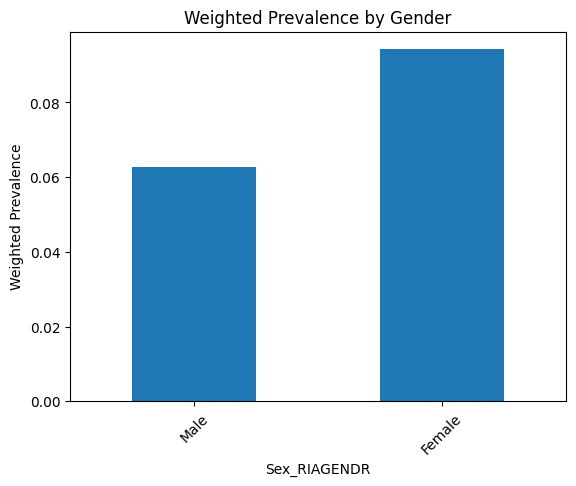

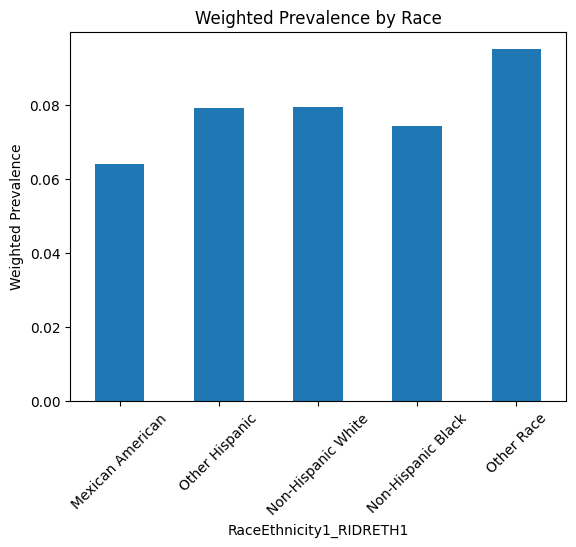

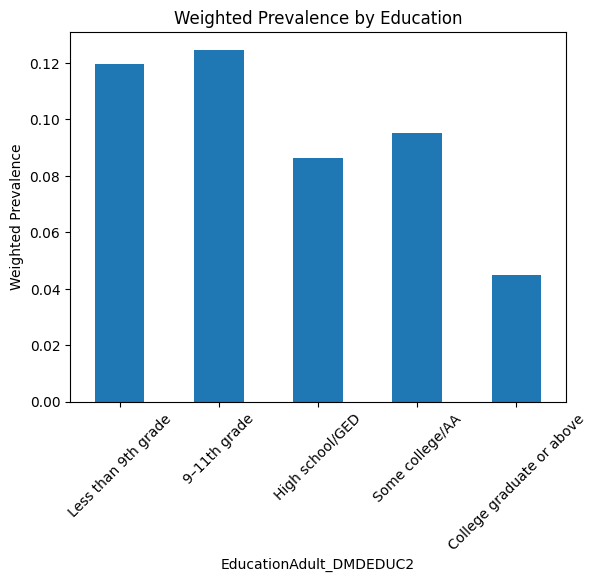

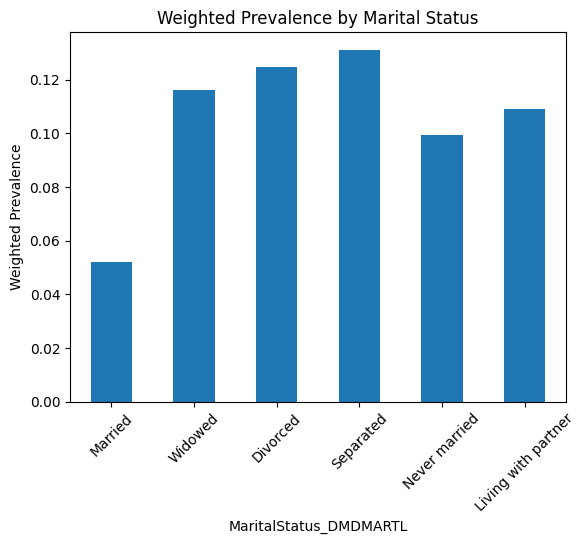

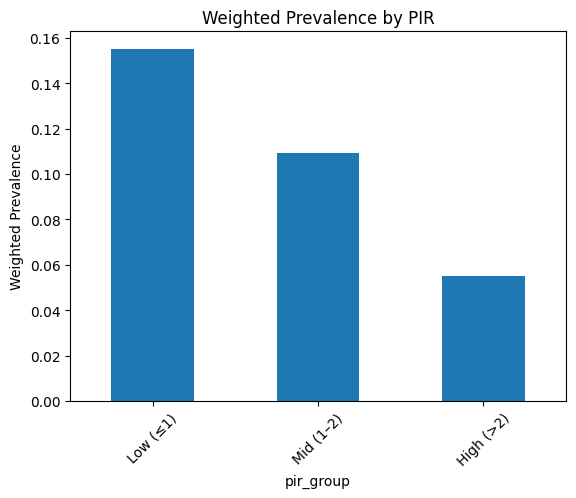

In [48]:
import matplotlib.pyplot as plt

def plot_bar(data, title):
    data.plot(kind="bar")
    plt.ylabel("Weighted Prevalence")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

# Plotting all
plot_bar(gender_prevalence, "Weighted Prevalence by Gender")
plot_bar(race_prevalence, "Weighted Prevalence by Race")
plot_bar(education_prevalence, "Weighted Prevalence by Education")
plot_bar(marital_prevalence, "Weighted Prevalence by Marital Status")
plot_bar(pir_prevalence, "Weighted Prevalence by PIR")

**Comments** Bar plots were used to visually represent the weighted prevalence of probable depression across sociodemographic groups. The values in the bar plots align with the previously calculated weighted prevalence values and provide a clear visual representation of the differences between them.